In [116]:
import pandas as pd

In [117]:
df = pd.read_csv("../data/processed/portugal_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84398 entries, 0 to 84397
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Price                  84398 non-null  float64
 1   District               84398 non-null  object 
 2   City                   84398 non-null  object 
 3   Town                   84398 non-null  object 
 4   Type                   84398 non-null  object 
 5   EnergyCertificate      84398 non-null  object 
 6   TotalArea              84389 non-null  float64
 7   Parking                84260 non-null  float64
 8   HasParking             42497 non-null  object 
 9   ConstructionYear       71568 non-null  float64
 10  EnergyEfficiencyLevel  41892 non-null  object 
 11  Garage                 41892 non-null  object 
 12  Elevator               84389 non-null  object 
 13  ElectricCarsCharging   41892 non-null  object 
 14  TotalRooms             62995 non-null  float64
 15  Nu

C:\Users\Yan\AppData\Local\Temp\ipykernel_11616\86041580.py:1: DtypeWarning: Columns (8,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/portugal_cleaned.csv")


# Etapa 1: Lidando com Missing Values

In [118]:
missing_values = df.isnull().sum()

missing_data = pd.DataFrame({"Valores ausentes": missing_values,
                             "Porcentagem (%)": (missing_values / len(df)) * 100})

missing_data = missing_data[missing_data["Valores ausentes"] > 0].sort_values(by="Porcentagem (%)", ascending=False)

missing_data


,Valores ausentes,Porcentagem (%)
LotSize,65478,77.582407
NumberOfWC,48657,57.651840
NumberOfBedrooms,42514,50.373232
ElectricCarsCharging,42506,50.363753
EnergyEfficiencyLevel,42506,50.363753
Garage,42506,50.363753
HasParking,41901,49.646911
TotalRooms,21403,25.359606
ConstructionYear,12830,15.201782
NumberOfBathrooms,425,0.503566


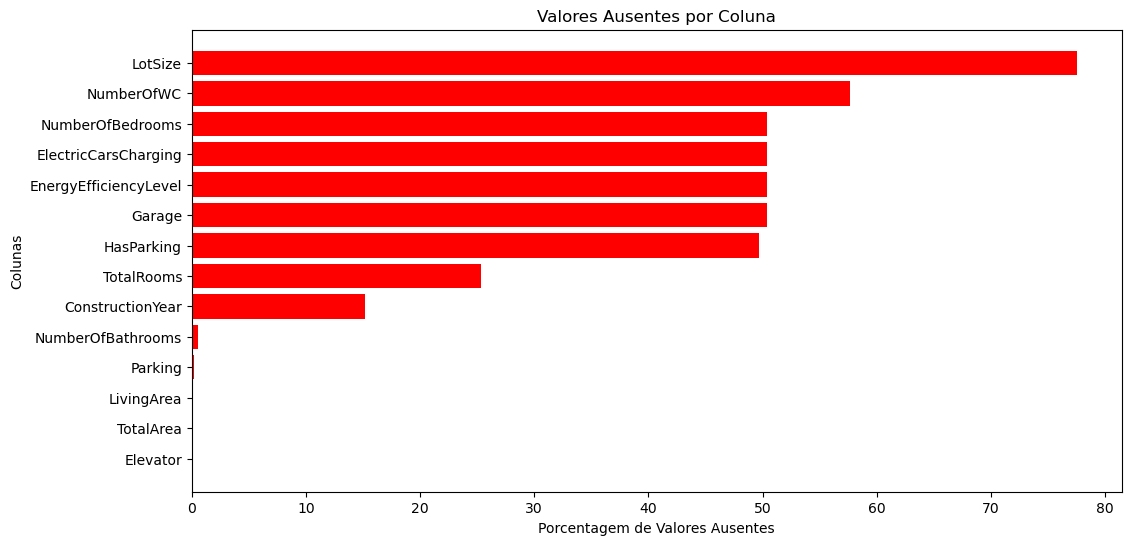

In [119]:
import matplotlib.pyplot as plt

# Criar um gráfico de barras para visualizar os valores ausentes
plt.figure(figsize=(12, 6))
plt.barh(missing_data.index, missing_data["Porcentagem (%)"], color="red")
plt.xlabel("Porcentagem de Valores Ausentes")
plt.ylabel("Colunas")
plt.title("Valores Ausentes por Coluna")
plt.gca().invert_yaxis()  # Inverter a ordem para melhor visualização
plt.show()


In [120]:
# Removendo a coluna LotSize, pois tem muitos valores ausentes

df = df.drop(columns=["LotSize", "EnergyEfficiencyLevel"])

In [121]:
# Preenchendo com zero os valores ausentes nas colunas seguintes, representando que não possui

cols_to_fill_zero = ["Garage", "HasParking", "ElectricCarsCharging", "Parking", "Elevator"]
df[cols_to_fill_zero] = df[cols_to_fill_zero].fillna(0)

In [122]:
# Removendo linhas onde TotalArea ou LivingArea são nulos

df = df.dropna(subset=["TotalArea", "LivingArea"])

# Resetar o índice do DataFrame após a remoção de linhas nulas
df = df.reset_index(drop=True)

# Verificando se ainda há valores nulos nessas colunas]

print(df[["TotalArea", "LivingArea"]].isnull().sum())


TotalArea     0
LivingArea    0
dtype: int64


In [123]:
# Preencher valores ausentes de NumberOfBathrooms com a mediana por tipo de imóvel
df["NumberOfBathrooms"] = df.groupby("Type")["NumberOfBathrooms"].transform(lambda x: x.fillna(x.median()))


In [124]:
# Substituindo os valores ausentes na coluna Construction Year por "Informação não disponível"

df.loc[:, "ConstructionYear"] = df["ConstructionYear"].astype("object").fillna("Informação não disponível")

C:\Users\Yan\AppData\Local\Temp\ipykernel_11616\326302833.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Informação não disponível' 'Informação não disponível'
 'Informação não disponível' ... 1937.0 1982.0 1987.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[:, "ConstructionYear"] = df["ConstructionYear"].astype("object").fillna("Informação não disponível")


In [125]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


# Selecionar as colunas relevantes para prever NumberOfBedrooms, NumberOfWC e TotalRooms
features = ["TotalArea", "LivingArea", "City", "District", "Type"]

# Criar uma cópia do dataset para evitar modificar o original diretamente
df_knn = df.copy()

# Transformar variáveis categóricas em numéricas usando Label Encoding
label_encoders = {}
for col in ["City", "District", "Type"]:
    le = LabelEncoder()
    df_knn[col] = le.fit_transform(df_knn[col].astype(str))  # Converter para string antes de aplicar LabelEncoder
    label_encoders[col] = le  # Armazenar os label encoders para uso futuro

# Selecionar as colunas a serem usadas para imputação (features + colunas com valores ausentes)
cols_to_impute = features + ["NumberOfBedrooms", "NumberOfWC", "TotalRooms"]

# Normalizar os dados para que o KNN funcione corretamente
scaler = MinMaxScaler()
df_knn[cols_to_impute] = scaler.fit_transform(df_knn[cols_to_impute])

# Criar e aplicar o KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[cols_to_impute] = knn_imputer.fit_transform(df_knn[cols_to_impute])

# Desnormalizar os dados de volta para a escala original
df_knn[cols_to_impute] = scaler.inverse_transform(df_knn[cols_to_impute])

# Resetar índice do df_knn para garantir compatibilidade antes da substituição
df_knn = df_knn.reset_index(drop=True)

# Atualizar os valores imputados no dataframe original
# df[["NumberOfBedrooms", "NumberOfWC", "TotalRooms"]] = df_knn[["NumberOfBedrooms", "NumberOfWC", "TotalRooms"]]


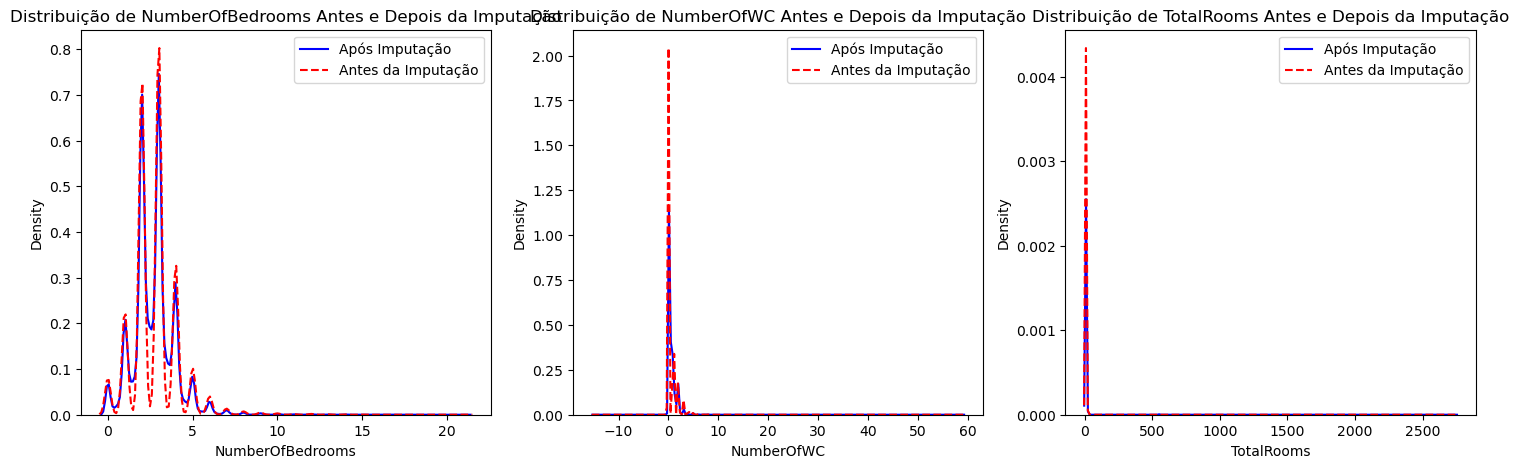

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar gráficos de distribuição antes e depois da imputação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variáveis que foram imputadas
cols_to_check = ["NumberOfBedrooms", "NumberOfWC", "TotalRooms"]

for i, col in enumerate(cols_to_check):
    # Plotar distribuição antes e depois
    sns.kdeplot(df_knn[col].dropna(), label="Após Imputação", ax=axes[i], color="blue")
    sns.kdeplot(df[col].dropna(), label="Antes da Imputação", ax=axes[i], color="red", linestyle="dashed")
    
    axes[i].set_title(f"Distribuição de {col} Antes e Depois da Imputação")
    axes[i].legend()

plt.show()


In [127]:
# Contar valores nulos no df original
print("Valores nulos no df original:")
print(df.isnull().sum())

# Contar valores nulos no df_knn (imputado)
print("\nValores nulos no df_knn:")
print(df_knn.isnull().sum())


Valores nulos no df original:
Price                       0
District                    0
City                        0
Town                        0
Type                        0
EnergyCertificate           0
TotalArea                   0
Parking                     0
HasParking                  0
ConstructionYear            0
Garage                      0
Elevator                    0
ElectricCarsCharging        0
TotalRooms              21384
NumberOfBedrooms        42490
NumberOfWC              48636
LivingArea                  0
NumberOfBathrooms           0
dtype: int64

Valores nulos no df_knn:
Price                   0
District                0
City                    0
Town                    0
Type                    0
EnergyCertificate       0
TotalArea               0
Parking                 0
HasParking              0
ConstructionYear        0
Garage                  0
Elevator                0
ElectricCarsCharging    0
TotalRooms              0
NumberOfBedrooms        0
N

In [128]:
df[["NumberOfBedrooms", "NumberOfWC", "TotalRooms", "NumberOfBathrooms"]] = df_knn[["NumberOfBedrooms", "NumberOfWC", "TotalRooms", "NumberOfBathrooms"]]


# Etapa 2: Lidando com Outliers

In [129]:
# Verificar estatísticas resumidas para identificar possíveis outliers
df.describe()


,Price,TotalArea,Parking,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,NumberOfBathrooms
count,8.436700e+04,8.436700e+04,84367.000000,84367.000000,84367.000000,84367.000000,84367.000000,84367.000000
mean,4.096690e+05,3.328571e+03,0.762703,3.225097,2.701535,0.523683,217.422452,2.062204
std,4.775776e+06,3.244436e+05,0.880339,9.987608,1.245613,0.772647,3764.576389,1.456069
min,1.000000e+00,-2.710000e+02,0.000000,0.000000,0.000000,-15.000000,0.000000,-13.000000
25%,1.699000e+05,8.400000e+01,0.000000,2.000000,2.000000,0.000000,78.000000,1.000000
50%,2.750000e+05,1.230000e+02,1.000000,3.000000,2.800000,0.200000,108.000000,2.000000
75%,4.420000e+05,2.200000e+02,1.000000,4.000000,3.200000,1.000000,163.000000,3.000000
max,1.380000e+09,5.621510e+07,3.000000,2751.000000,21.000000,59.000000,470300.000000,131.000000


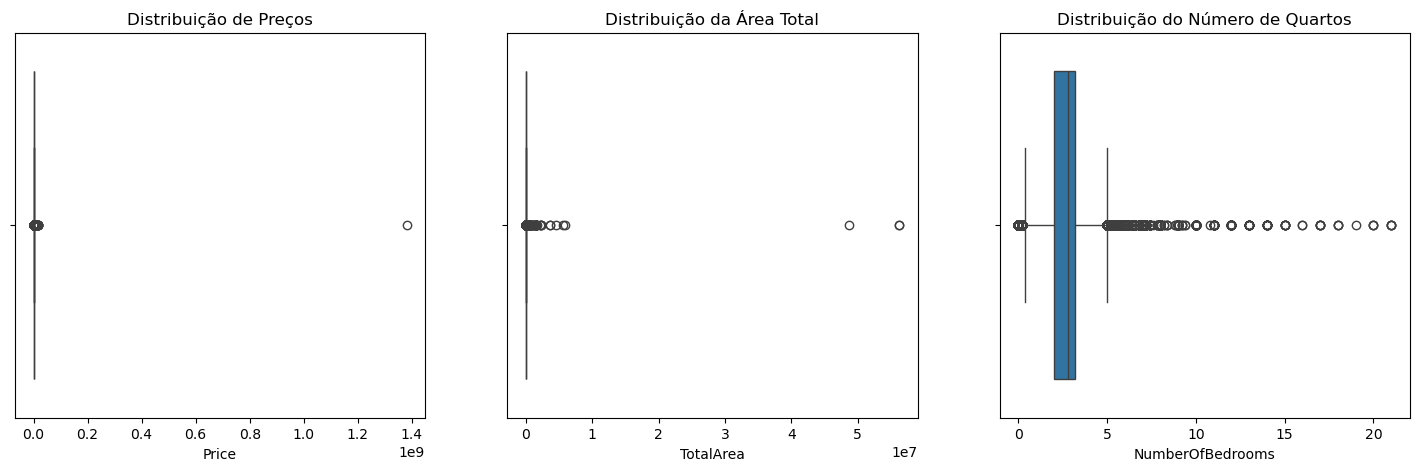

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar boxplots para as principais variáveis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df["Price"], ax=axes[0])
axes[0].set_title("Distribuição de Preços")

sns.boxplot(x=df["TotalArea"], ax=axes[1])
axes[1].set_title("Distribuição da Área Total")

sns.boxplot(x=df["NumberOfBedrooms"], ax=axes[2])
axes[2].set_title("Distribuição do Número de Quartos")

plt.show()


In [131]:
# Contar quantas linhas têm valores negativos
negativos = (df[["TotalArea", "LivingArea", "NumberOfBathrooms", "NumberOfWC"]] < 0).sum()
print(negativos)


TotalArea             6
LivingArea            0
NumberOfBathrooms     3
NumberOfWC           16
dtype: int64


In [132]:
# Remover todas as linhas que possuem valores negativos em colunas críticas
df = df[(df["TotalArea"] > 0) & 
        (df["LivingArea"] > 0) & 
        (df["NumberOfBathrooms"] >= 0) & 
        (df["NumberOfWC"] >= 0)]


In [133]:
# Verificar estatísticas após a remoção de valores negativos
df.describe()

,Price,TotalArea,Parking,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,NumberOfBathrooms
count,8.359900e+04,8.359900e+04,83599.000000,83599.000000,83599.000000,83599.000000,83599.000000,83599.000000
mean,4.079687e+05,3.358377e+03,0.762605,3.231398,2.706528,0.526217,218.755787,2.062764
std,4.796965e+06,3.259303e+05,0.879472,10.032105,1.245854,0.771671,3781.798602,1.456186
min,1.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.690000e+05,8.500000e+01,0.000000,2.000000,2.000000,0.000000,78.000000,1.000000
50%,2.745000e+05,1.240000e+02,1.000000,3.000000,2.800000,0.200000,108.000000,2.000000
75%,4.400000e+05,2.210000e+02,1.000000,4.000000,3.200000,1.000000,163.000000,3.000000
max,1.380000e+09,5.621510e+07,3.000000,2751.000000,21.000000,59.000000,470300.000000,131.000000


In [134]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[column] >= limite_inferior) & (df[column] <= limite_superior)]

# Aplicar o filtro em colunas com valores extremos
columns_to_filter = ["Price", "TotalArea", "LivingArea", "TotalRooms", "NumberOfBedrooms", "NumberOfWC", "NumberOfBathrooms"]

for col in columns_to_filter:
    df = remove_outliers(df, col)


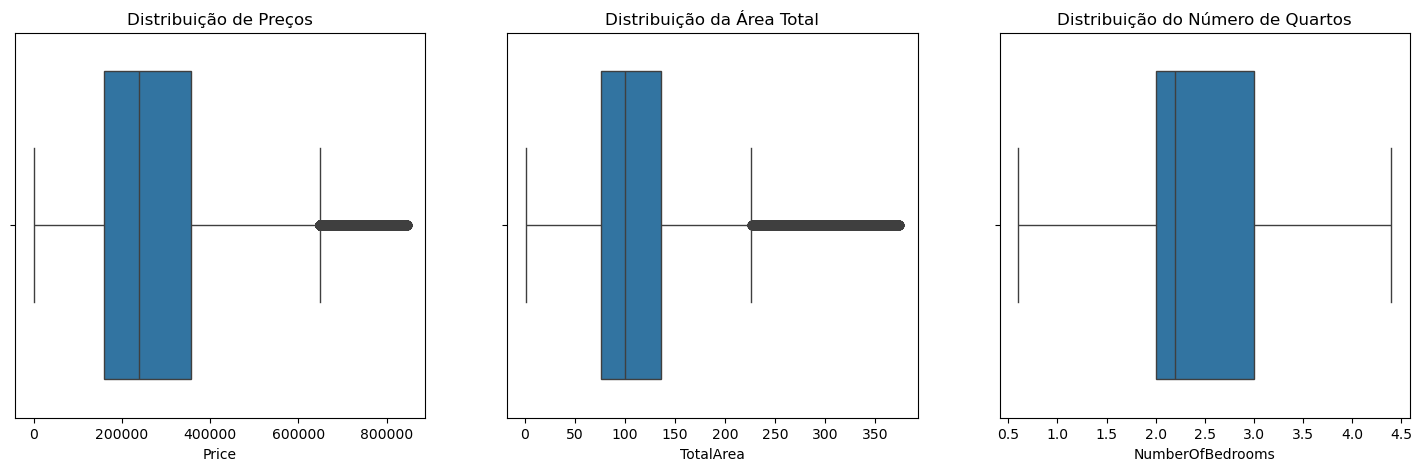

In [135]:
# Criar boxplots para as principais variáveis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df["Price"], ax=axes[0])
axes[0].set_title("Distribuição de Preços")

sns.boxplot(x=df["TotalArea"], ax=axes[1])
axes[1].set_title("Distribuição da Área Total")

sns.boxplot(x=df["NumberOfBedrooms"], ax=axes[2])
axes[2].set_title("Distribuição do Número de Quartos")

plt.show()

In [136]:
# Verificar estatísticas após a remoção de valores negativos
df.describe()

,Price,TotalArea,Parking,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,NumberOfBathrooms
count,53492.000000,53492.000000,53492.000000,53492.000000,53492.000000,53492.000000,53492.000000,53492.000000
mean,272836.082049,114.098071,0.595846,2.709624,2.344818,0.340391,98.852071,1.617793
std,166050.531085,58.486789,0.708376,1.009486,0.784094,0.422202,39.951639,0.796235
min,1.000000,1.000000,0.000000,0.000000,0.600000,0.000000,1.000000,0.000000
25%,160000.000000,76.000000,0.000000,2.000000,2.000000,0.000000,70.000000,1.000000
50%,240000.000000,100.000000,0.000000,3.000000,2.200000,0.200000,92.000000,2.000000
75%,355900.000000,136.000000,1.000000,3.000000,3.000000,0.600000,120.000000,2.000000
max,845000.000000,374.000000,3.000000,5.400000,4.400000,1.800000,233.000000,3.000000


In [137]:
df.to_csv("../data/processed/portugal_real_estate_outliers_cleaned.csv", index=False)